In [1]:
import tensorflow as tf

# List available physical GPU devices
print("Available GPU devices:", tf.config.list_physical_devices('GPU'))

# Check if GPU support is available
print("Is GPU available:", tf.test.is_gpu_available())


Available GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
Is GPU available: True


In [2]:
import numpy
import cv2
import keras
import tensorflow
print("NumPy version:", numpy.__version__)
print("OpenCV-Python-Headless version:", cv2.__version__)
print("Keras version:", keras.__version__)
print("TensorFlow version:", tensorflow.__version__)


NumPy version: 1.26.4
OpenCV-Python-Headless version: 4.9.0
Keras version: 2.10.0
TensorFlow version: 2.10.1


In [3]:
import os##for working with file dir
import random ##create randow umber
import pandas as pd##use for manuplation and analysis
import numpy as np##working with materic and arrays
import matplotlib.pyplot as plt## to plts the graph
import seaborn as sns ###more addvance than matplotlib.pyplot
import cv2##used for various image processing tasks

In [4]:
#Set Parameters
im_width = 256
im_height = 256

Load image path and mask path

In [ ]:
##seprate the dataon the base of mask
import glob#ile pattern matching
train_files = []
mask_files = glob.glob('D:\datascience video\Datasets\DATA/lgg-mri-segmentation/kaggle_3m/*/*_mask*')
# the mask file and append to train file
for i in mask_files:
    train_files.append(i.replace('_mask',''))
print(train_files[:10])
print(mask_files[:10])

['D:\\datascience video\\Datasets\\DATA/lgg-mri-segmentation/kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_10.tif', 'D:\\datascience video\\Datasets\\DATA/lgg-mri-segmentation/kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_11.tif', 'D:\\datascience video\\Datasets\\DATA/lgg-mri-segmentation/kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_12.tif', 'D:\\datascience video\\Datasets\\DATA/lgg-mri-segmentation/kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_13.tif', 'D:\\datascience video\\Datasets\\DATA/lgg-mri-segmentation/kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_14.tif', 'D:\\datascience video\\Datasets\\DATA/lgg-mri-segmentation/kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_15.tif', 'D:\\datascience video\\Datasets\\DATA/lgg-mri-segmentation/kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_16.tif', 'D:\\datascience video\\Datasets\\DATA/lgg-mri-segmentation/kaggle_3m\\TCGA_CS_4941_19960909\\TCGA_CS_4941_19960909_17.tif',

Data Visualization

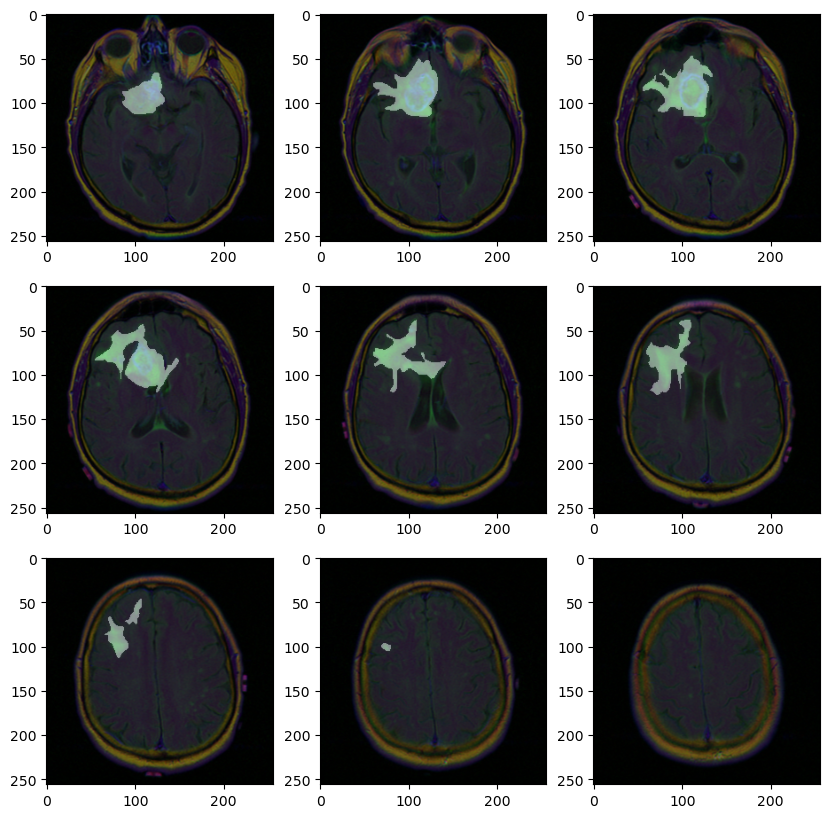

In [6]:
#create 10by10 image
fig=plt.figure(figsize=(10,10))
rows,cols=3,3
for i in range(1,rows*cols+1):#run for all the image
    fig.add_subplot(rows,cols,i)#add grid on the image
    img_path=train_files[i]#run for both dir images
    msk_path=mask_files[i]
    img=cv2.imread(img_path)#obtain file path for image and its mask
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)#convert image into RGB
    msk=cv2.imread(msk_path)#read mask image
    plt.imshow(img)#show image
    plt.imshow(msk,alpha=0.4)#apply 0.4 mask transparency on image
plt.show()

Create Data Frame and and split data on train set, validation set and test set

In [7]:
from sklearn.model_selection import train_test_split
df = pd.DataFrame(data={"filename": train_files, 'mask' : mask_files})
#create data freames then divide the data for testing trean and validation
df_train, df_test = train_test_split(df,test_size = 0.1)
df_train, df_val = train_test_split(df_train,test_size = 0.2)
print(df_train.values.shape)
print(df_val.values.shape)
print(df_test.values.shape)

(2828, 2)
(708, 2)
(393, 2)


Data genertator, data augmentation and adjust data

In [8]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")  # Use the 'ggplot' style for plots, which gives them a particular look similar to ggplot in R.
%matplotlib inline  # Display Matplotlib plots inline in Jupyter notebooks.

import cv2  # OpenCV for image processing.
from tqdm import tqdm_notebook, tnrange  # tqdm for showing progress bars in loops and Jupyter notebooks.
from glob import glob  # Glob for finding all the pathnames matching a specified pattern.
from itertools import chain  # Chain for combining multiple iterables into a single sequence.
from skimage.io import imread, imshow, concatenate_images  # scikit-image for reading, showing, and concatenating images.
from skimage.transform import resize  # scikit-image for resizing images.
from skimage.morphology import label  # scikit-image for labeling connected regions in binary images.
from sklearn.model_selection import train_test_split  # scikit-learn for splitting data into training and testing sets.

import tensorflow as tf  # TensorFlow for building and training neural networks.
from skimage.color import rgb2gray  # scikit-image for converting RGB images to grayscale.
from tensorflow.keras import Input  # Keras (in TensorFlow) for defining input layers.
from tensorflow.keras.models import Model, load_model, save_model  # Keras for creating, loading, and saving models.
from tensorflow.keras.layers import Input, Activation, BatchNormalization, Dropout, Lambda, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate  # Keras layers for building neural networks.
from tensorflow.keras.optimizers import Adam  # Keras optimizer for training neural networks.
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint  # Keras callbacks for early stopping and saving the best model.
from tensorflow.keras import backend as K  # Keras backend for performing operations with different backends (e.g., TensorFlow, Theano).
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Keras for augmenting image data.


In [ ]:
#This function generates batches of images and their corresponding masks simultaneously,
# ensuring that the same transformations (such as rotation, scaling, etc.) 
#are applied to both. This is crucial for training image segmentation models 
#where the input image and the output mask need to correspond accurately.
def train_generator(data_frame, batch_size, aug_dict,
        image_color_mode="rgb",
        mask_color_mode="grayscale",
        image_save_prefix="image",
        mask_save_prefix="mask",
        save_to_dir=None,
        target_size=(256,256),
        seed=1):
    '''
    Generates images and masks simultaneously.
    Ensures that the same augmentations are applied to both images and masks
    by using the same seed for image_datagen and mask_datagen.
    If you want to visualize the results of the generator, set save_to_dir to your desired path.
    '''
    # Create an image data generator with the specified augmentations
    image_datagen = ImageDataGenerator(**aug_dict)
    # Create a mask data generator with the same augmentations
    mask_datagen = ImageDataGenerator(**aug_dict)

    # Flow images from the dataframe
    image_generator = image_datagen.flow_from_dataframe(
        data_frame,
        x_col="filename",  # Column with image filenames
        class_mode=None,  # No class mode since it's not a classification task
        color_mode=image_color_mode,  # Color mode for images
        target_size=target_size,  # Resize images to target size
        batch_size=batch_size,  # Number of images per batch
        save_to_dir=save_to_dir,  # Directory to save images (for visualization)
        save_prefix=image_save_prefix,  # Prefix for saved images
        seed=seed)  # Seed for reproducibility

    # Flow masks from the dataframe
    mask_generator = mask_datagen.flow_from_dataframe(
        data_frame,
        x_col="mask",  # Column with mask filenames
        class_mode=None,  # No class mode since it's not a classification task
        color_mode=mask_color_mode,  # Color mode for masks
        target_size=target_size,  # Resize masks to target size
        batch_size=batch_size,  # Number of masks per batch
        save_to_dir=save_to_dir,  # Directory to save masks (for visualization)
        save_prefix=mask_save_prefix,  # Prefix for saved masks
        seed=seed)  # Seed for reproducibility

    # Zip the image and mask generators to ensure they are synchronized
    train_gen = zip(image_generator, mask_generator)

    # Iterate over the combined generator
    for (img, mask) in train_gen:
        # Adjust the images and masks (normalize and binarize masks)
        img, mask = adjust_data(img, mask)
        yield (img, mask)  # Yield the processed images and masks

def adjust_data(img, mask):
    # Normalize image pixel values to the range [0, 1]
    img = img / 255
    # Normalize mask pixel values to the range [0, 1]
    mask = mask / 255
    # Binarize the masks: set pixels > 0.5 to 1, and <= 0.5 to 0
    mask[mask > 0.5] = 1
    mask[mask <= 0.5] = 0

    return (img, mask)  # Return the processed image and mask


Define loss function and metrics

In [10]:
smooth = 100  # Smoothing factor to avoid division by zero in calculations.
#The Dice coefficient is a metric that measures the overlap between two samples.
# It ranges from 0 (no overlap) to 1 (perfect overlap). It's commonly used in image segmentation tasks.
def dice_coef(y_true, y_pred):
    # Flatten the true and predicted tensors to 1D arrays.
    y_truef = K.flatten(y_true)
    y_predf = K.flatten(y_pred)
    # Calculate the intersection of the true and predicted values.
    And = K.sum(y_truef * y_predf)
    # Compute the Dice coefficient.
    return (2 * And + smooth) / (K.sum(y_truef) + K.sum(y_predf) + smooth)
#The Dice coefficient loss is used to train the model. 
#It is defined as the negative Dice coefficient so that minimizing the loss maximizes the Dice coefficient.
def dice_coef_loss(y_true, y_pred):
    # The Dice loss is defined as the negative of the Dice coefficient.
    return -dice_coef(y_true, y_pred)
#IoU, also known as the Jaccard Index,
# is another metric for evaluating the accuracy of image segmentation models. It measures the overlap between the true and predicted masks.
def iou(y_true, y_pred):
    # Calculate the intersection of the true and predicted values.
    intersection = K.sum(y_true * y_pred)
    # Calculate the sum of the true and predicted values.
    sum_ = K.sum(y_true + y_pred)
    # Compute the Intersection over Union (IoU) or Jaccard Index.
    jac = (intersection + smooth) / (sum_ - intersection + smooth)
    return jac
#The Jaccard distance is used as a loss function for training segmentation models.
# It is defined as the negative IoU, so minimizing the Jaccard distance maximizes the IoU.

def jac_distance(y_true, y_pred):
    # Flatten the true and predicted tensors to 1D arrays.
    y_truef = K.flatten(y_true)
    y_predf = K.flatten(y_pred)
    # The Jaccard distance is defined as the negative of the IoU.
    return -iou(y_true, y_pred)


define unet

In [11]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, BatchNormalization, Activation, concatenate
#defines the U-Net model. input_size specifies the shape of the input images.
def unet(input_size=(256,256,3)):
    inputs = Input(input_size)
#model starts with two convolutional layers followed by batch normalization and ReLU activation.
# Then, max-pooling is applied to reduce spatial dimensions.
    conv1 = Conv2D(32, (3, 3), padding='same')(inputs)
    bn1 = BatchNormalization()(conv1)
    bn1 = Activation('relu')(bn1)
    conv1 = Conv2D(32, (3, 3), padding='same')(bn1)
    bn1 = BatchNormalization()(conv1)
    bn1 = Activation('relu')(bn1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(bn1)

#Similar layers are repeated to extract features at different scales.
    conv2 = Conv2D(64, (3, 3), padding='same')(pool1)
    bn2 = BatchNormalization()(conv2)
    bn2 = Activation('relu')(bn2)
    conv2 = Conv2D(64, (3, 3), padding='same')(bn2)
    bn2 = BatchNormalization()(conv2)
    bn2 = Activation('relu')(bn2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(bn2)

    conv3 = Conv2D(128, (3, 3), padding='same')(pool2)
    bn3 = BatchNormalization()(conv3)
    bn3 = Activation('relu')(bn3)
    conv3 = Conv2D(128, (3, 3), padding='same')(bn3)
    bn3 = BatchNormalization()(conv3)
    bn3 = Activation('relu')(bn3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(bn3)

    conv4 = Conv2D(256, (3, 3), padding='same')(pool3)
    bn4 = BatchNormalization()(conv4)
    bn4 = Activation('relu')(bn4)
    conv4 = Conv2D(256, (3, 3), padding='same')(bn4)
    bn4 = BatchNormalization()(conv4)
    bn4 = Activation('relu')(bn4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(bn4)

    conv5 = Conv2D(512, (3, 3), padding='same')(pool4)
    bn5 = BatchNormalization()(conv5)
    bn5 = Activation('relu')(bn5)
    conv5 = Conv2D(512, (3, 3), padding='same')(bn5)
    bn5 = BatchNormalization()(conv5)
    bn5 = Activation('relu')(bn5)
    pool5 = MaxPooling2D(pool_size=(2, 2))(bn5)
#The deepest layer captures high-level semantic information.
    conv6 = Conv2D(1024, (3, 3), padding='same')(pool5)
    bn6 = BatchNormalization()(conv6)
    bn6 = Activation('relu')(bn6)
    conv6 = Conv2D(1024, (3, 3), padding='same')(bn6)
    bn6 = BatchNormalization()(conv6)
    bn6 = Activation('relu')(bn6)
#Transposed convolution (or upsampling) is applied to upsample the feature maps and concatenate them with feature maps from the contracting path
    up7 = concatenate([Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(bn6), conv5], axis=3)
    conv7 = Conv2D(512, (3, 3), padding='same')(up7)
    bn7 = BatchNormalization()(conv7)
    bn7 = Activation('relu')(bn7)
    conv7 = Conv2D(512, (3, 3), padding='same')(bn7)
    bn7 = BatchNormalization()(conv7)
    bn7 = Activation('relu')(bn7)

    up8 = concatenate([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(bn7), conv4], axis=3)
    conv8 = Conv2D(256, (3, 3), padding='same')(up8)
    bn8 = BatchNormalization()(conv8)
    bn8 = Activation('relu')(bn8)
    conv8 = Conv2D(256, (3, 3), padding='same')(bn8)
    bn8 = BatchNormalization()(conv8)
    bn8 = Activation('relu')(bn8)

    up9 = concatenate([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(bn8), conv3], axis=3)
    conv9 = Conv2D(128, (3, 3), padding='same')(up9)
    bn9 = BatchNormalization()(conv9)
    bn9 = Activation('relu')(bn9)
    conv9 = Conv2D(128, (3, 3), padding='same')(bn9)
    bn9 = BatchNormalization()(conv9)
    bn9 = Activation('relu')(bn9)

    up10 = concatenate([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(bn9), conv2], axis=3)
    conv10 = Conv2D(64, (3, 3), padding='same')(up10)
    bn10 = BatchNormalization()(conv10)
    bn10 = Activation('relu')(bn10)
    conv10 = Conv2D(64, (3, 3), padding='same')(bn10)
    bn10 = BatchNormalization()(conv10)
    bn10 = Activation('relu')(bn10)

    up11 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(bn10), conv1], axis=3)
    conv11 = Conv2D(64, (3, 3), padding='same')(up11)
    bn11 = BatchNormalization()(conv11)
    bn11 = Activation('relu')(bn11)
    conv11 = Conv2D(64, (3, 3), padding='same')(bn11)
    bn11 = BatchNormalization()(conv11)
    bn11 = Activation('relu')(bn11)
#Finally, a 1x1 convolution with sigmoid activation is applied to generate the segmentation mask.
    conv12 = Conv2D(1, (1, 1), activation='sigmoid')(bn11)
#The model is instantiated and returned as a Keras Model
    return Model(inputs=[inputs], outputs=[conv12])


In [12]:
model = unet()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 32  896         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 256, 256, 32  128        ['conv2d[0][0]']                 
 alization)                     )                                                             

Training

In [13]:
#the number of times the entire dataset will pass through the network during training.
EPOCHS = 20
##defines the number of samples that will be propagated through the network before the model's internal parameters (weights) are updated.
BATCH_SIZE = 10
# critical hyperparameter that controls the rate at which the model learns. Here, it's set to 0.0001 
learning_rate = 1e-4

In [18]:
# Dictionary containing augmentation parameters for the training data generator
train_generator_args = dict(
    rotation_range=0.2,           # Randomly rotate images by 20 degrees
    width_shift_range=0.05,       # Randomly shift images horizontally by 5%
    height_shift_range=0.05,      # Randomly shift images vertically by 5%
    shear_range=0.05,             # Randomly shear images by 5%
    zoom_range=0.05,              # Randomly zoom into images by 5%
    horizontal_flip=True,         # Randomly flip images horizontally
    fill_mode='nearest'           # Fill mode for newly created pixels during transformations
)

# Create the training data generator with the specified augmentation parameters and batch size
train_gen = train_generator(
    df_train,                     # DataFrame containing training data file paths
    BATCH_SIZE,                   # Number of samples per gradient update
    train_generator_args,         # Augmentation parameters
    target_size=(im_height, im_width)  # Target size for the images
)

# Create the validation data generator without any augmentation
test_gener = train_generator(
    df_val,                       # DataFrame containing validation data file paths
    BATCH_SIZE,                   # Number of samples per gradient update
    dict(),                       # No augmentation for validation data
    target_size=(im_height, im_width)  # Target size for the images
)

# Instantiate the U-Net model with the specified input size
model = unet(input_size=(im_height, im_width, 3))

# Calculate the learning rate decay rate
decay_rate = learning_rate / EPOCHS

# Instantiate the Adam optimizer with the specified learning rate and default parameters
opt = tf.keras.optimizers.Adam(
    learning_rate=0.001,          # Initial learning rate
    beta_1=0.9,                   # Exponential decay rate for the 1st moment estimates
    beta_2=0.999,                 # Exponential decay rate for the 2nd moment estimates
    epsilon=1e-07,                # Small constant for numerical stability
    amsgrad=False,                # Whether to apply the AMSGrad variant of Adam
    name='Adam'                   # Name of the optimizer
)

# Compile the model with the Adam optimizer, Dice coefficient loss function, and additional metrics
model.compile(
    optimizer=opt,                # Optimizer
    loss=dice_coef_loss,          # Loss function
    metrics=["binary_accuracy", iou, dice_coef]  # Additional metrics to track during training
)

# Define the callbacks for model checkpointing
callbacks = [ModelCheckpoint(
    'unet_brain_mri_seg.hdf5',    # Filepath to save the model
    verbose=1,                    # Verbosity mode, 1 = output messages
    save_best_only=True           # Save only the best model based on the validation loss
)]

# Train the model using the training and validation generators
history = model.fit(
    train_gen,                    # Training data generator
    steps_per_epoch=int(len(df_train) / BATCH_SIZE),  # Number of steps per epoch
    epochs=EPOCHS,                # Number of epochs to train the model
    callbacks=callbacks,          # List of callbacks to apply during training
    validation_data=test_gener,   # Validation data generator
    validation_steps=int(len(df_val) / BATCH_SIZE)  # Number of steps for validation
)


Found 2828 validated image filenames.
Found 2828 validated image filenames.
Epoch 1/20
282/282 [==============================] - ETA: 0s - loss: -0.3395 - binary_accuracy: 0.9657 - iou: 0.2342 - dice_coef: 0.3395Found 708 validated image filenames.
Found 708 validated image filenames.

Epoch 1: val_loss improved from inf to -0.05386, saving model to unet_brain_mri_seg.hdf5
282/282 [==============================] - 82s 278ms/step - loss: -0.3395 - binary_accuracy: 0.9657 - iou: 0.2342 - dice_coef: 0.3395 - val_loss: -0.0539 - val_binary_accuracy: 0.6741 - val_iou: 0.0282 - val_dice_coef: 0.0539
Epoch 2/20
282/282 [==============================] - ETA: 0s - loss: -0.5677 - binary_accuracy: 0.9923 - iou: 0.4334 - dice_coef: 0.5678
Epoch 2: val_loss improved from -0.05386 to -0.49243, saving model to unet_brain_mri_seg.hdf5
282/282 [==============================] - 78s 276ms/step - loss: -0.5677 - binary_accuracy: 0.9923 - iou: 0.4334 - dice_coef: 0.5678 - val_loss: -0.4924 - val_binar

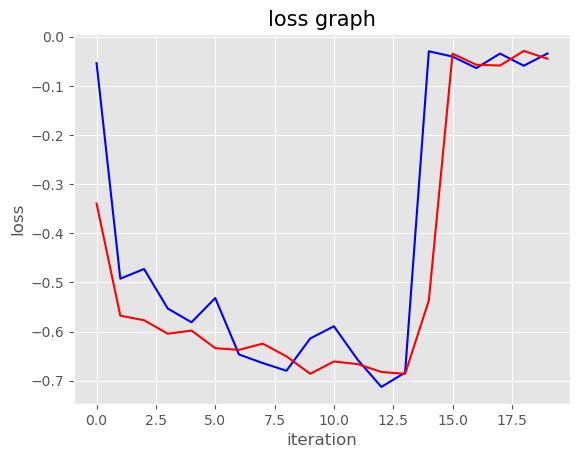

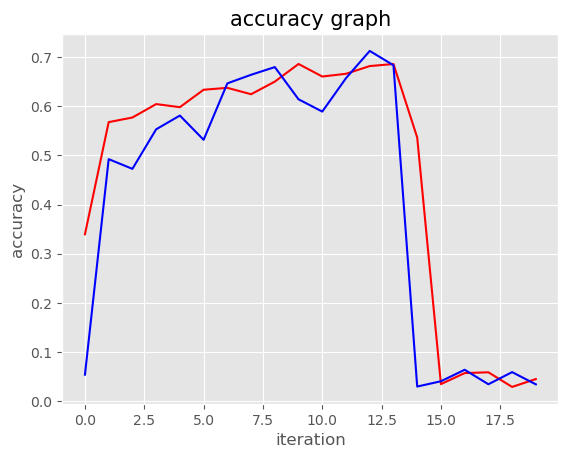

In [19]:
# Extract the training history
a = history.history

# Lists of training and validation metrics
list_traindice = a['dice_coef']        # Training Dice coefficient
list_testdice = a['val_dice_coef']     # Validation Dice coefficient

list_trainjaccard = a['iou']           # Training IoU (Jaccard index)
list_testjaccard = a['val_iou']        # Validation IoU (Jaccard index)

list_trainloss = a['loss']             # Training loss
list_testloss = a['val_loss']          # Validation loss

# Plotting the loss graph
plt.figure(1)
plt.plot(list_testloss, 'b-', label='Validation Loss')  # Validation loss in blue
plt.plot(list_trainloss, 'r-', label='Training Loss')   # Training loss in red
plt.xlabel('Epoch')                                     # Label for x-axis
plt.ylabel('Loss')                                      # Label for y-axis
plt.title('Loss Graph', fontsize=15)                    # Title of the plot
plt.legend()                                            # Show legend
plt.grid(True)                                          # Show grid
plt.show()

# Plotting the accuracy graph (Dice coefficient)
plt.figure(2)
plt.plot(list_traindice, 'r-', label='Training Dice Coefficient')  # Training Dice coefficient in red
plt.plot(list_testdice, 'b-', label='Validation Dice Coefficient') # Validation Dice coefficient in blue
plt.xlabel('Epoch')                                                # Label for x-axis
plt.ylabel('Dice Coefficient')                                     # Label for y-axis
plt.title('Dice Coefficient Graph', fontsize=15)                   # Title of the plot
plt.legend()                                                       # Show legend
plt.grid(True)                                                     # Show grid
plt.show()

# Plotting the IoU graph
plt.figure(3)
plt.plot(list_trainjaccard, 'r-', label='Training IoU')   # Training IoU in red
plt.plot(list_testjaccard, 'b-', label='Validation IoU')  # Validation IoU in blue
plt.xlabel('Epoch')                                       # Label for x-axis
plt.ylabel('IoU (Jaccard Index)')                         # Label for y-axis
plt.title('IoU Graph', fontsize=15)                       # Title of the plot
plt.legend()                                              # Show legend
plt.grid(True)                                            # Show grid
plt.show()


In [20]:
from keras.models import load_model

model = load_model('unet_brain_mri_seg.hdf5', custom_objects={'dice_coef_loss': dice_coef_loss, 'iou': iou, 'dice_coef': dice_coef})


In [21]:
test_gen = train_generator(df_test, BATCH_SIZE,
                                dict(),
                                target_size=(im_height, im_width))
results = model.evaluate(test_gen, steps=len(df_test) / BATCH_SIZE)
print("Test lost: ",results[0])
print("Test IOU: ",results[1])
print("Test Dice Coefficent: ",results[2])

Found 393 validated image filenames.
Found 393 validated image filenames.
39/39 [==============================] - 5s 113ms/step - loss: -0.6695 - binary_accuracy: 0.9936 - iou: 0.5350 - dice_coef: 0.6696
Test lost:  -0.6695493459701538
Test IOU:  0.9935739040374756
Test Dice Coefficent:  0.5350170731544495


1/1 [==============================] - 1s 550ms/step


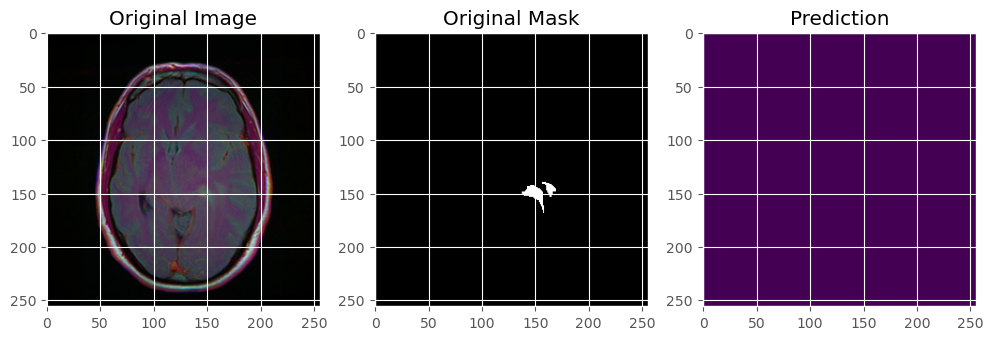

1/1 [==============================] - 0s 24ms/step


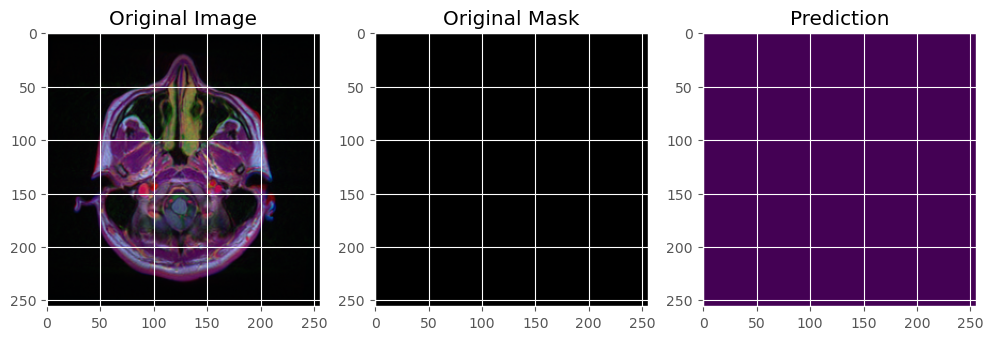

1/1 [==============================] - 0s 20ms/step


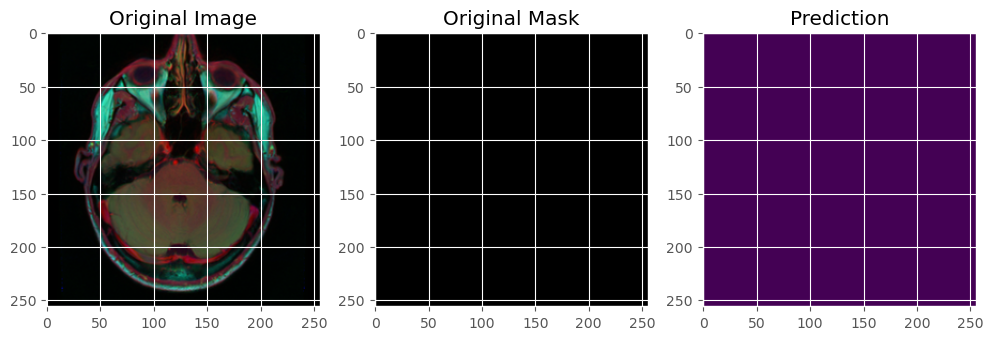

1/1 [==============================] - 0s 20ms/step


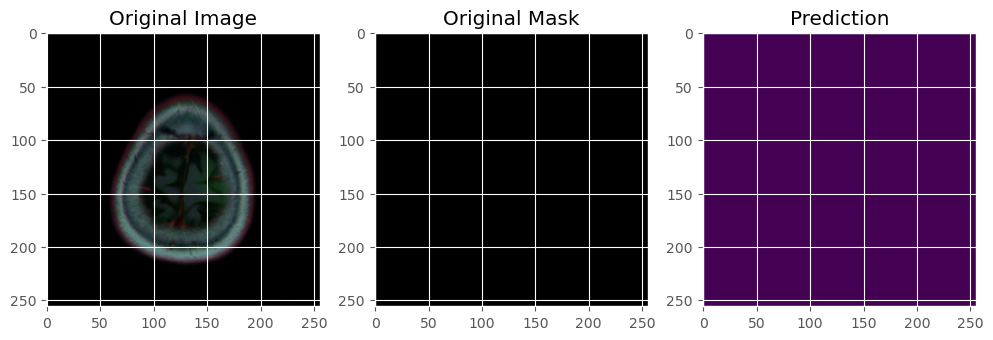

1/1 [==============================] - 0s 22ms/step


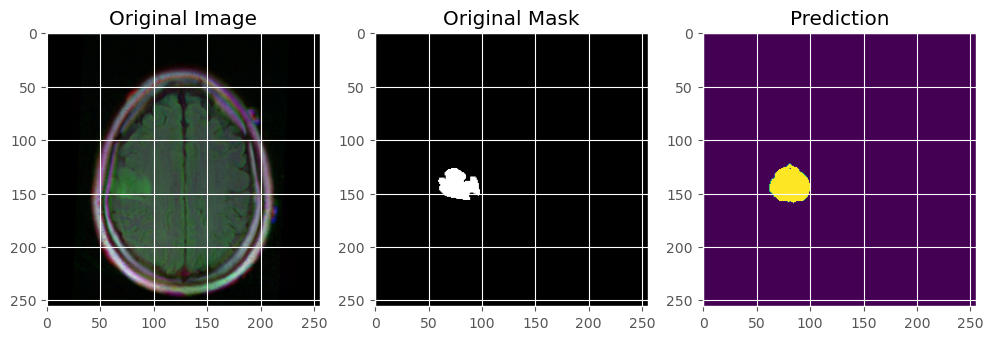

1/1 [==============================] - 0s 21ms/step


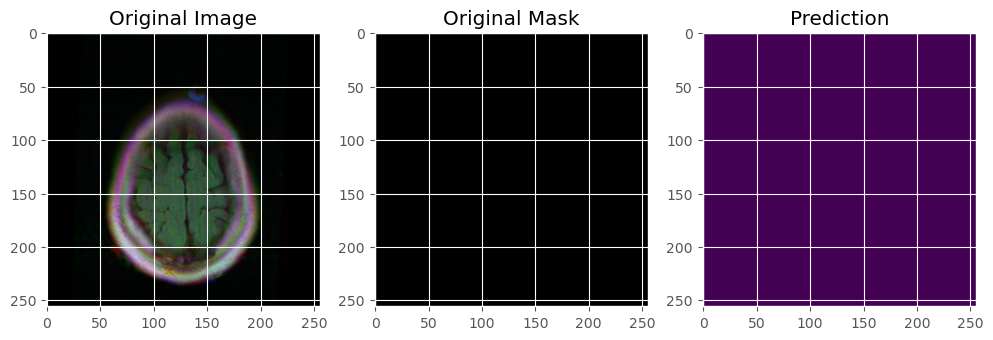

1/1 [==============================] - 0s 22ms/step


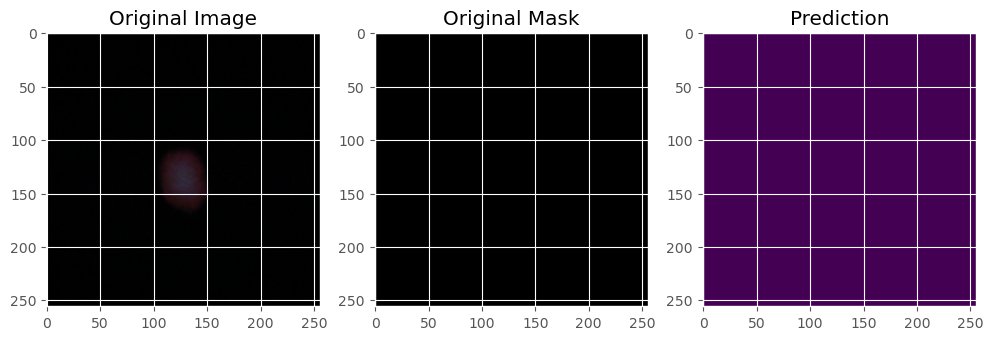

1/1 [==============================] - 0s 26ms/step


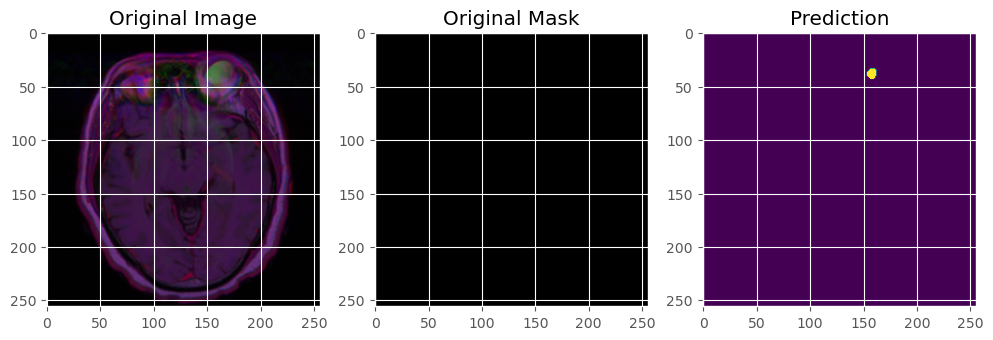

1/1 [==============================] - 0s 22ms/step


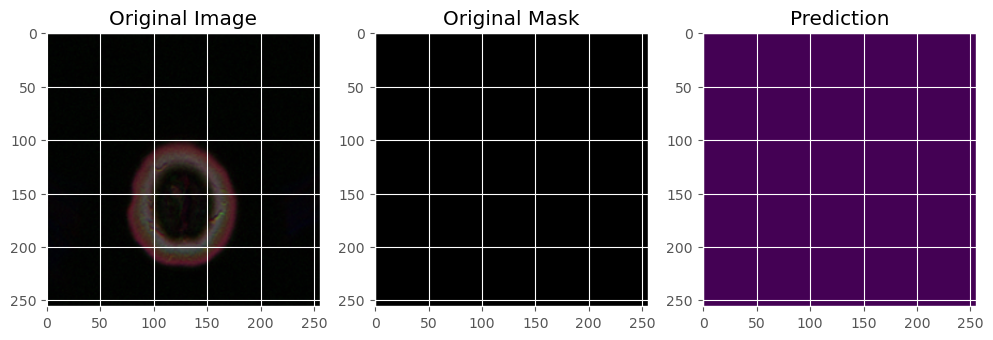

1/1 [==============================] - 0s 21ms/step


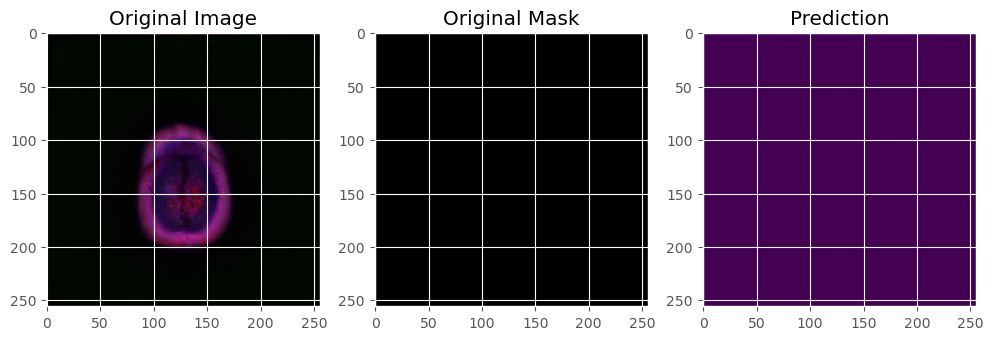

1/1 [==============================] - 0s 22ms/step


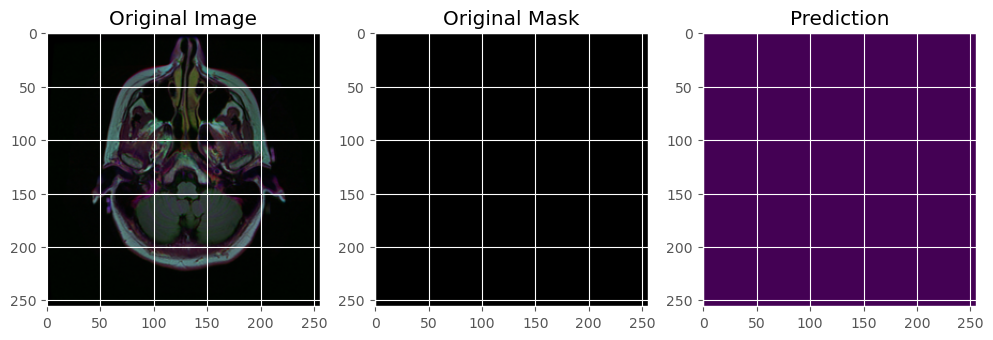

1/1 [==============================] - 0s 29ms/step


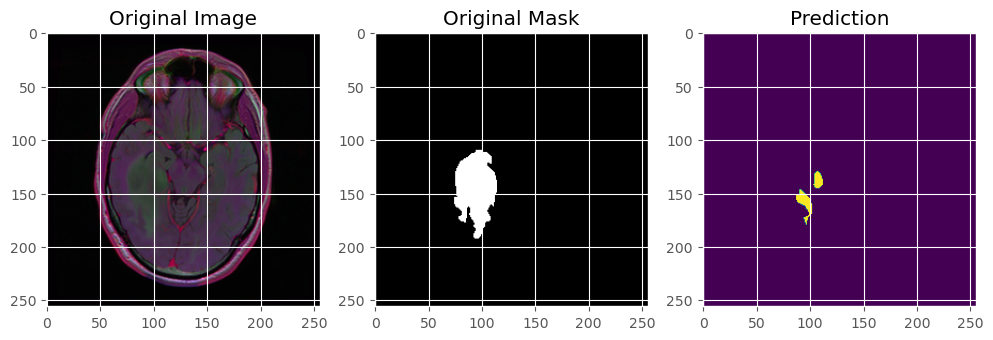

1/1 [==============================] - 0s 29ms/step


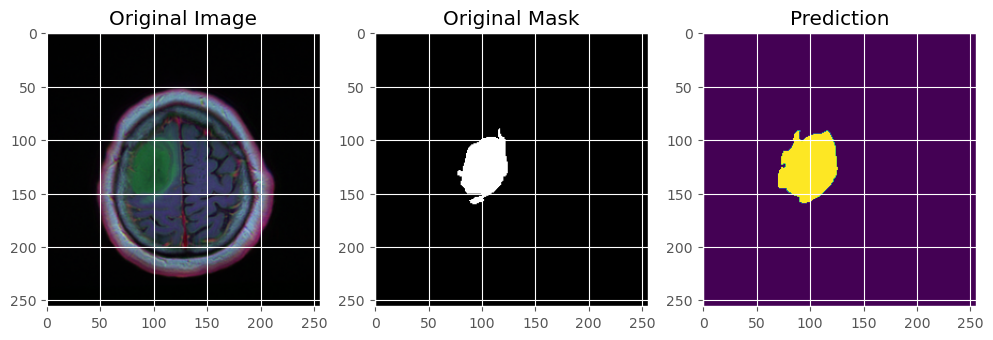

1/1 [==============================] - 0s 20ms/step


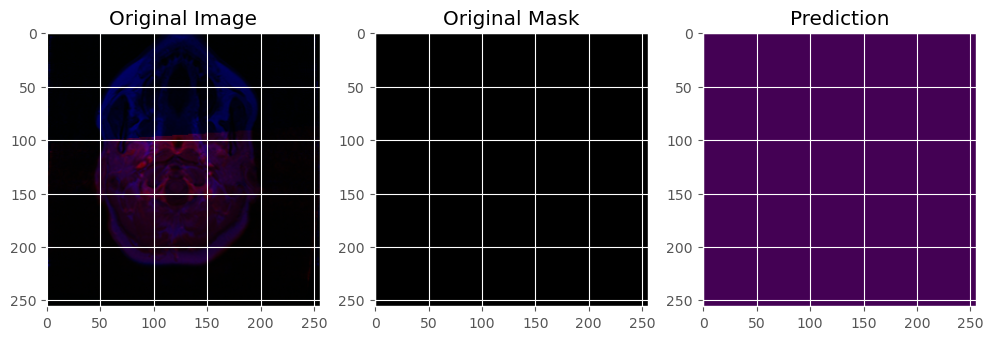

1/1 [==============================] - 0s 19ms/step


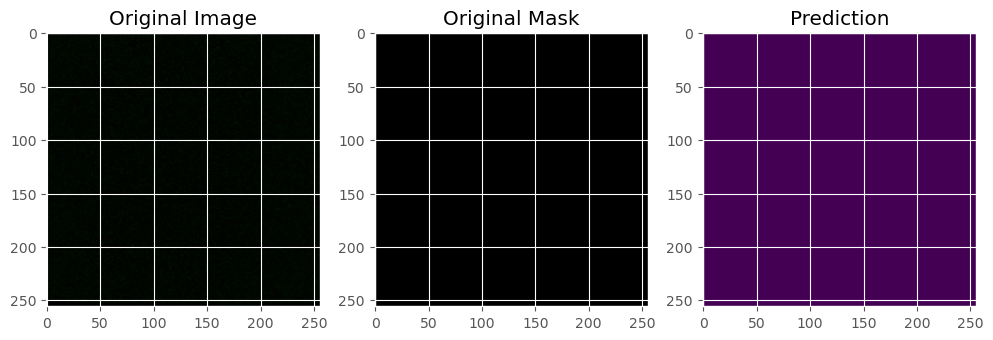

1/1 [==============================] - 0s 21ms/step


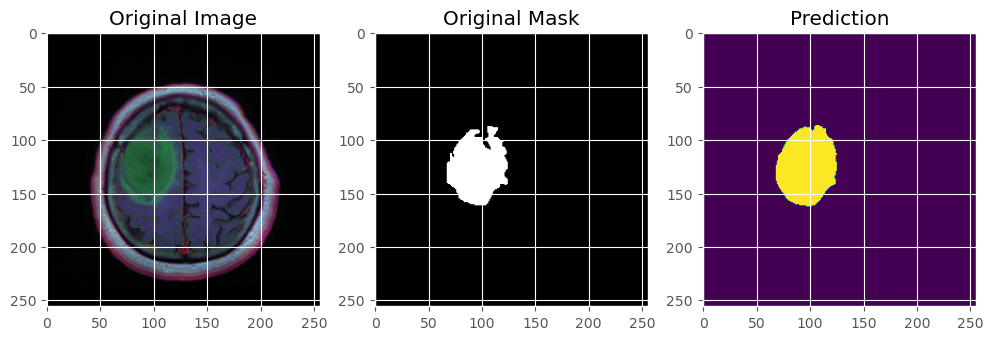

1/1 [==============================] - 0s 20ms/step


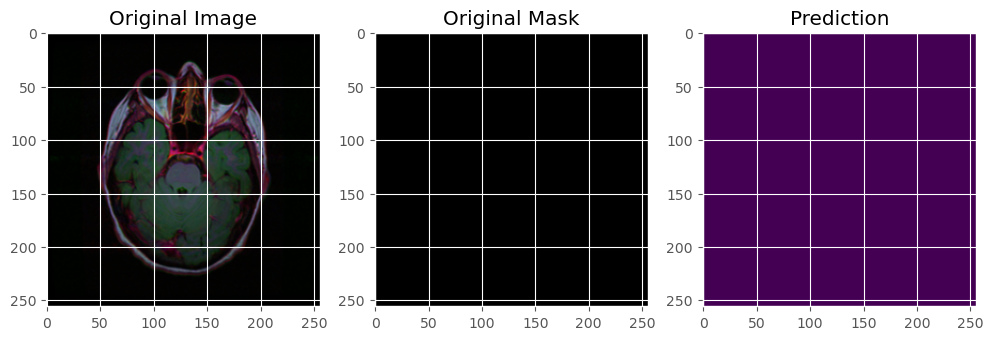

1/1 [==============================] - 0s 25ms/step


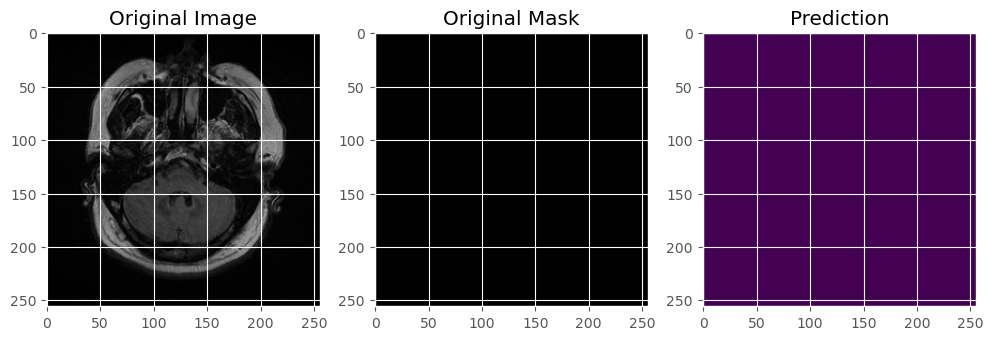

1/1 [==============================] - 0s 28ms/step


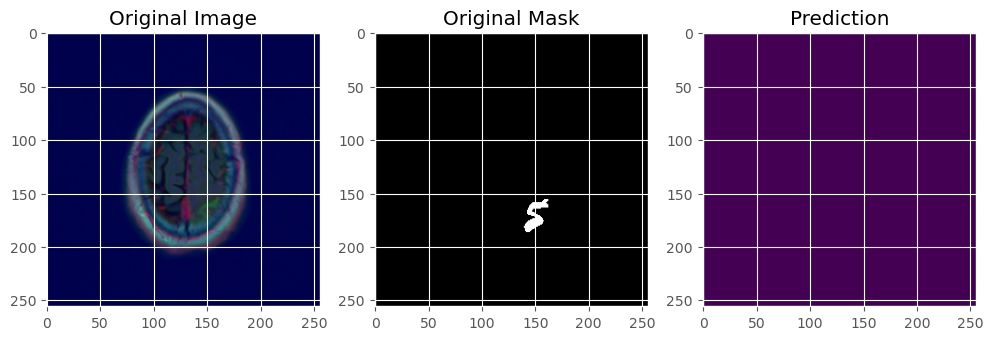

1/1 [==============================] - 0s 27ms/step


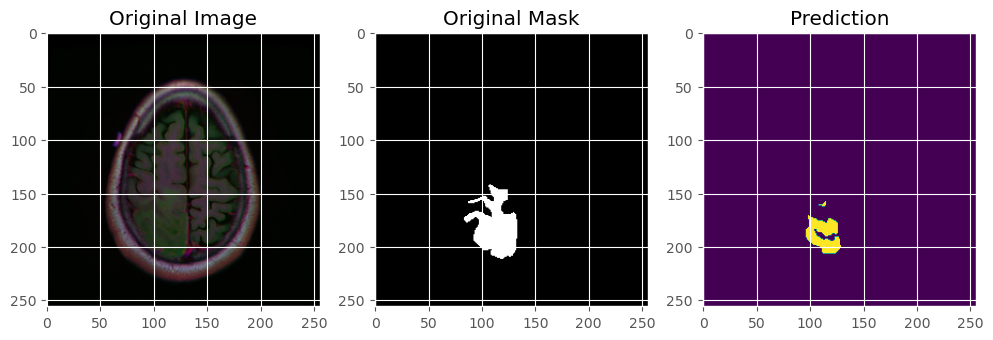

1/1 [==============================] - 0s 26ms/step


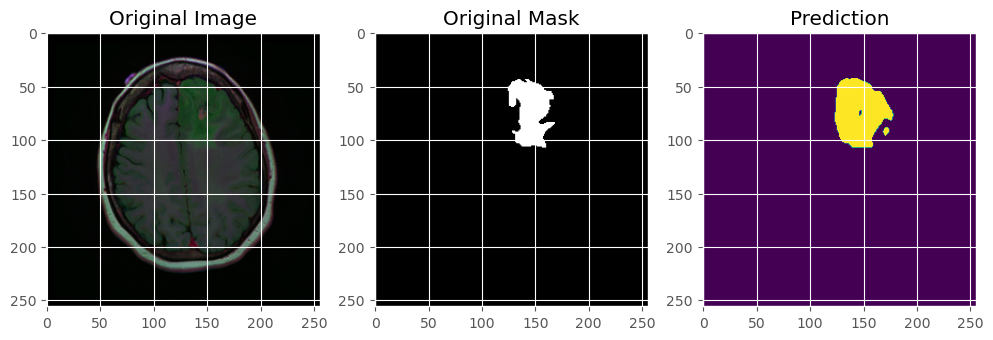

1/1 [==============================] - 0s 22ms/step


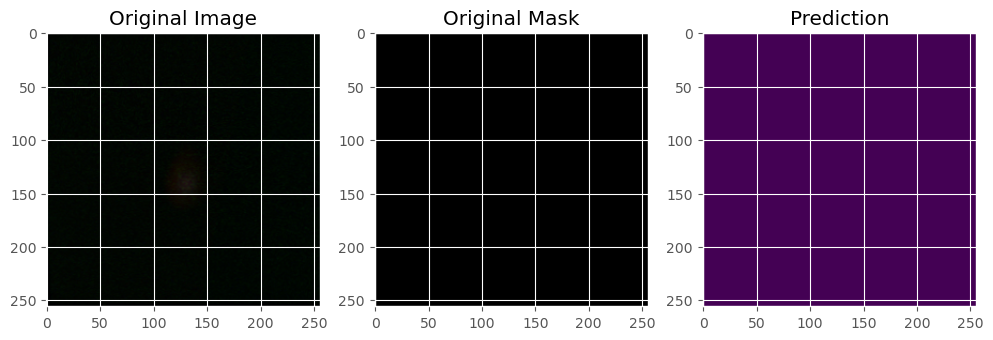

1/1 [==============================] - 0s 26ms/step


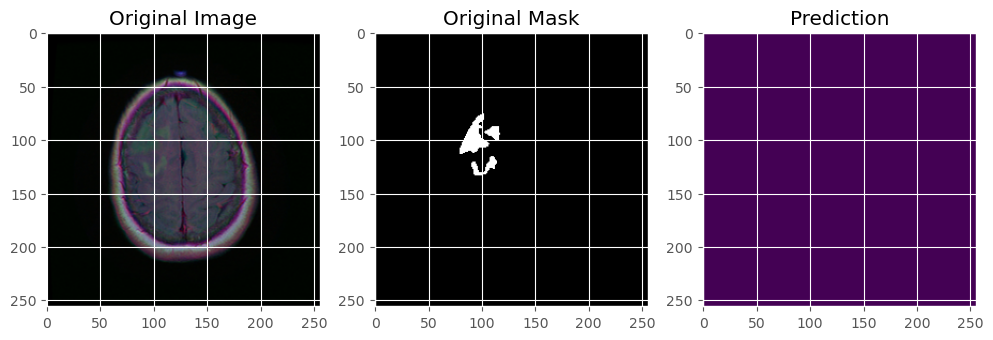

1/1 [==============================] - 0s 25ms/step


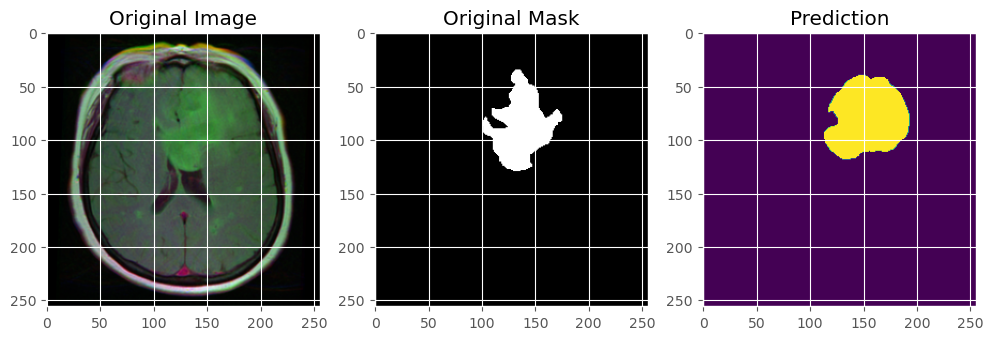

1/1 [==============================] - 0s 31ms/step


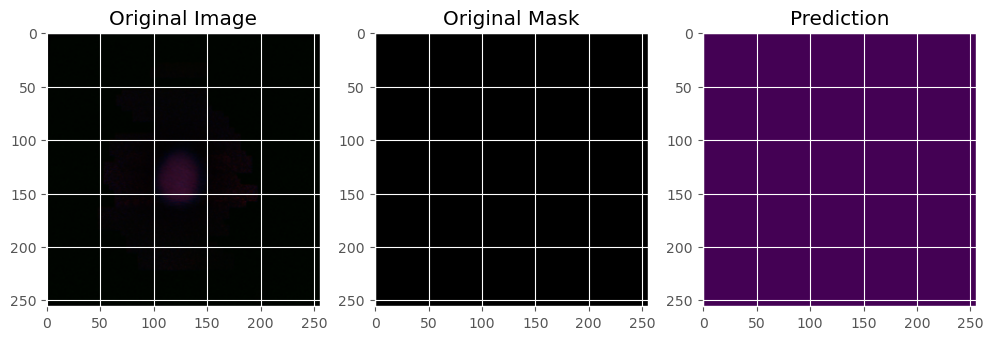

1/1 [==============================] - 0s 22ms/step


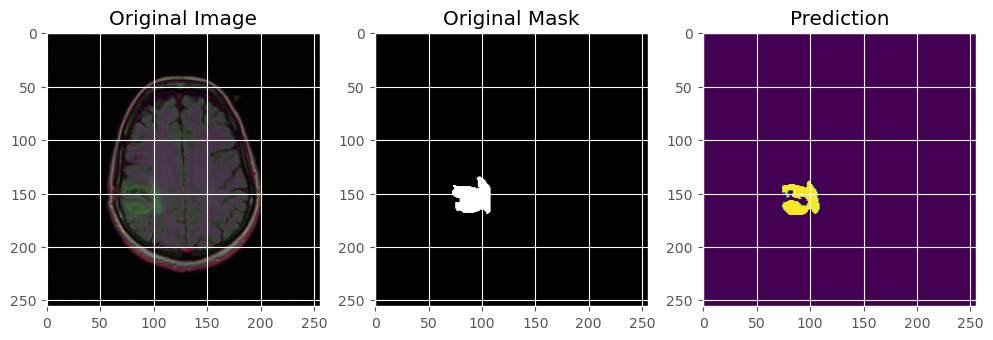

1/1 [==============================] - 0s 21ms/step


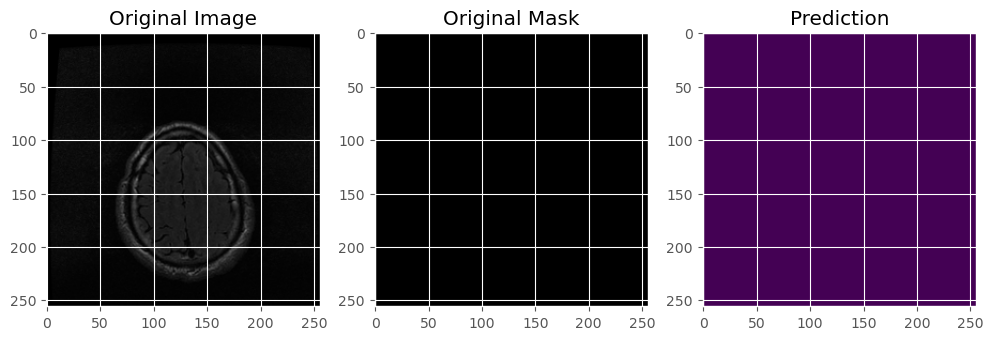

1/1 [==============================] - 0s 27ms/step


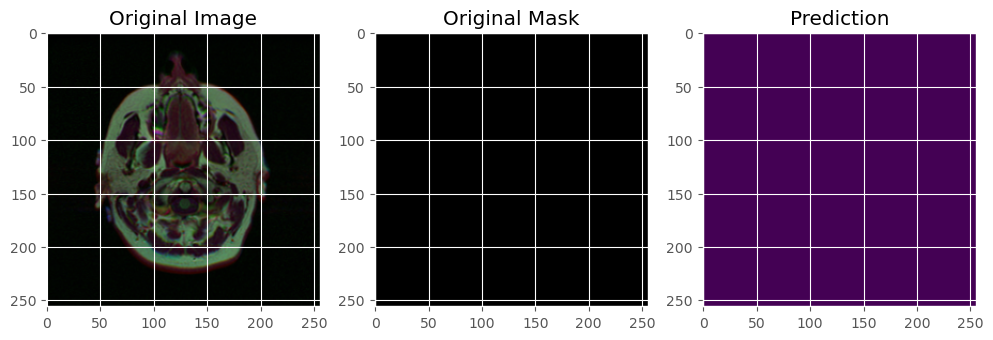

1/1 [==============================] - 0s 25ms/step


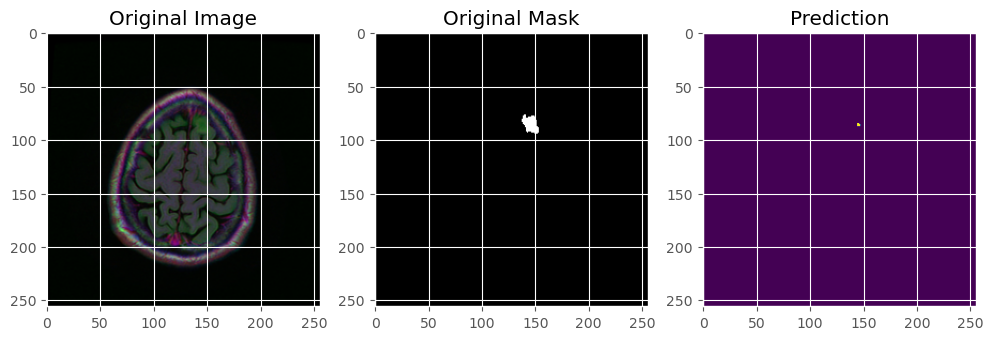

1/1 [==============================] - 0s 21ms/step


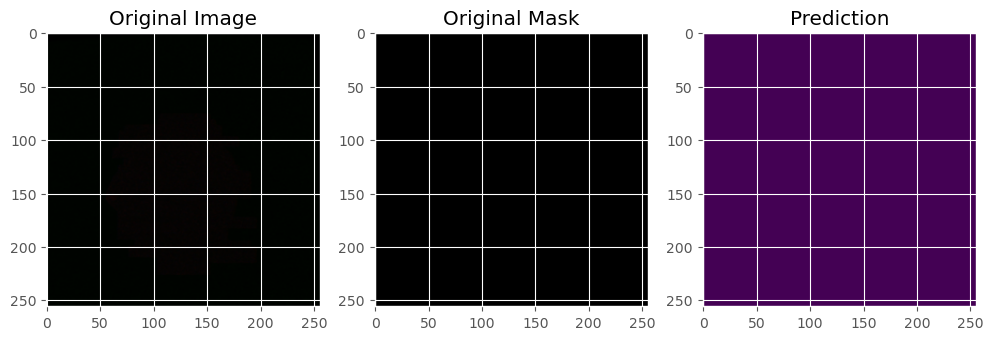

In [22]:
for i in range(30):
    index=np.random.randint(1,len(df_test.index))
    img = cv2.imread(df_test['filename'].iloc[index])
    img = cv2.resize(img ,(im_height, im_width))
    img = img / 255
    img = img[np.newaxis, :, :, :]
    pred=model.predict(img)

    plt.figure(figsize=(12,12))
    plt.subplot(1,3,1)
    plt.imshow(np.squeeze(img))
    plt.title('Original Image')
    plt.subplot(1,3,2)
    plt.imshow(np.squeeze(cv2.imread(df_test['mask'].iloc[index])))
    plt.title('Original Mask')
    plt.subplot(1,3,3)
    plt.imshow(np.squeeze(pred) > .5)
4    plt.title('Prediction')
plt.show()